# 06｜历史相似行情与 2026 敏感度机制分析

本 Notebook 是诊断分析入口，不修改冻结运行包的信号、阈值、持有参数或输出格式。

它读取：

- 本地米筐 CSI500 现货；
- 03 已生成的含持有期精简八列表；
- 事件型八列表和冻结参考，用于逐列一致性审计；
- 冻结 1545 内部面板，用于机制诊断。

输出包括历史相似行情、市场环境与内部状态分解、多视角同步与确认诊断、固定开发期锚定代理、相似阶段未来表现和本地/远端一致性审计。历史窗口的排序只使用窗口结束时已经可见的信息，后续收益只作为事后评价。

In [1]:
from pathlib import Path
import json
import os
import sys
import pandas as pd
from IPython.display import display

PACKAGE_ROOT = Path(os.environ.get(
    'FINAL_UPLOAD_PACKAGE_ROOT',
    '/home/hzy/cta/20260824_1805_冻结中证500输出包',
)).expanduser().resolve()
SRC_ROOT = (PACKAGE_ROOT / 'src').resolve()
if not PACKAGE_ROOT.is_absolute() or not SRC_ROOT.is_absolute():
    raise RuntimeError('06 的包路径必须是绝对路径')
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

def absolute_env(name, default):
    value = os.environ.get(name, default).strip()
    path = Path(value).expanduser().resolve()
    if not path.is_absolute():
        raise RuntimeError(f'{name} 必须是绝对路径：{value}')
    return path

SPOT_PATH = absolute_env('COMPANY_SPOT_PATH', '/home/hzy/cta/IC数据更新_最终固化版/现货最终版/CSI500_SPOT_md_eod_raw_最终版.parquet')
HOLDING_PATH = absolute_env('HOLDING_EIGHT_PATH', str(PACKAGE_ROOT / 'runtime_outputs_holding_period' / '含持有期八列表.csv'))
EVENT_PATH = absolute_env('EVENT_EIGHT_PATH', str(PACKAGE_ROOT / 'runtime_outputs' / '最终执行日简表.csv'))
EXPECTED_PATH = absolute_env('EXPECTED_EIGHT_PATH', str(PACKAGE_ROOT / '本地结果对照/01_只用现货生成八列/最终执行日简表.csv'))
STAGE04_DIR = absolute_env('ANALYSIS_04_OUTPUT_DIR', str(PACKAGE_ROOT / 'runtime_outputs_04_returns'))
OUTPUT_DIR = absolute_env('ANALYSIS_06_OUTPUT_DIR', str(PACKAGE_ROOT / 'runtime_outputs_06_mechanism'))
# 06 只使用 COMPANY_SPOT_PATH；内部1545面板由同一份现货重建，不读取外部 PANEL_PATH。
PANEL_PATH = None

from reproduce_stage_06 import run_stage_06

print('包目录：', PACKAGE_ROOT)
print('本地米筐现货：', SPOT_PATH)
print('事件型八列表：', EVENT_PATH)
print('含持有期八列表：', HOLDING_PATH)
print('06 输出目录：', OUTPUT_DIR)

包目录： /Users/hzy/Desktop/0817合并查看/20260824_1805_冻结中证500输出包
本地米筐现货： /Users/hzy/Desktop/0817合并查看/99_中间归档/本地数据快照_不入库/_rq_latest_20260824_1750/CSI500_SPOT_md_eod_raw_RQ_20260817.parquet
事件型八列表： /Users/hzy/Desktop/0817合并查看/20260824_1805_冻结中证500输出包/runtime_outputs/最终执行日简表.csv
含持有期八列表： /Users/hzy/Desktop/0817合并查看/20260824_1805_冻结中证500输出包/runtime_outputs_holding_period/含持有期八列表.csv
06 输出目录： /Users/hzy/Desktop/0817合并查看/20260824_1805_冻结中证500输出包/runtime_outputs_06_mechanism


## 1. 运行 06 分析

事件型八列和含持有期八列在审计中分开处理：前者与冻结参考逐列比较，后者只用于连续持有路径和收益分析。

In [2]:
metadata = run_stage_06(
    SPOT_PATH,
    HOLDING_PATH,
    OUTPUT_DIR,
    EXPECTED_PATH,
    STAGE04_DIR,
    PANEL_PATH,
    EVENT_PATH,
)
print(json.dumps(metadata['audit'], ensure_ascii=False, indent=2))
print('历史相似窗口：', metadata['analogue_dates'])
print('图像数量：', len(metadata['figures']))
print('表格数量：', len(metadata['tables']))

[06] 读取本地现货： /Users/hzy/Desktop/0817合并查看/99_中间归档/本地数据快照_不入库/_rq_latest_20260824_1750/CSI500_SPOT_md_eod_raw_RQ_20260817.parquet
[06] 读取含持有期八列表： /Users/hzy/Desktop/0817合并查看/20260824_1805_冻结中证500输出包/runtime_outputs_holding_period/含持有期八列表.csv
[06] 读取冻结参数参考： /Users/hzy/Desktop/0817合并查看/20260824_1805_冻结中证500输出包/本地结果对照/01_只用现货生成八列/最终执行日简表.csv
[06] 重建执行日期帧： 2097 2018-01-03 2026-08-25
{
  "spot_path": "/Users/hzy/Desktop/0817合并查看/99_中间归档/本地数据快照_不入库/_rq_latest_20260824_1750/CSI500_SPOT_md_eod_raw_RQ_20260817.parquet",
  "spot_sha256": "15b188c20208a73574d1727019f3a78a9f7d4210648a14ec9bc16834d3c2cbba",
  "spot_rows": 5256,
  "spot_date_min": "2005-01-04",
  "spot_date_max": "2026-08-24",
  "event_signal_path": "/Users/hzy/Desktop/0817合并查看/20260824_1805_冻结中证500输出包/runtime_outputs/最终执行日简表.csv",
  "local_event_signal_rows": 2097,
  "holding_path_rows": 2097,
  "reference_common_rows": 2097,
  "reference_date_max": "2026-08-25",
  "signal_mismatch_total": 0,
  "signal_mismatch_by_column": {
    "三状态

## 2. 关键表格

下面的指标只用于诊断和解释，不会回写冻结参数。

In [3]:
tables = OUTPUT_DIR / 'tables'
audit = pd.read_csv(tables / '本地远端一致性审计摘要.csv', encoding='utf-8-sig')
analogs = pd.read_csv(tables / '历史相似行情候选_60日.csv', encoding='utf-8-sig')
annual = pd.read_csv(tables / '年度行情机制与收益对比.csv', encoding='utf-8-sig')
display(audit)
display(analogs)
display(annual.tail(8))

,check,value,pass
0,local event signal values vs freeze reference ...,0 mismatches / 2097 rows,True
1,03 holding path is intentionally expanded from...,not compared cell-for-cell,True
2,04 state/date output matches regenerated execu...,True,True
3,local core metrics vs remote reference,14/18 metrics within tolerance,False
4,latest row has real signal values,2026-08-24 -> 2026-08-25,True
5,signal generation uses no future labels,metadata/engine boundary,True


,label,window_end,rank,return_20,return_60,return_120,vol_20,vol_60,drawdown_60,range_20,...,positive_sync_mean_60,negative_sync_mean_60,neutral_share_60,switch_rate_60,distance,forward_return_20,forward_return_60,forward_vol_20,future_switches_20,future_directional_days_20
0,2026当前窗口,2026-08-24,0,-0.000455,-0.076855,-0.108710,0.332123,0.351251,-0.145525,0.023523,...,1.016667,1.983333,0.550000,0.133333,0.000000,NaN,NaN,NaN,NaN,NaN
1,历史相似1,2020-04-10,1,-0.051944,-0.039693,0.029146,0.330720,0.362422,-0.116861,0.025519,...,1.550000,1.466667,0.700000,0.083333,0.786925,0.062930,0.281832,0.169645,2.0,5.0
2,历史相似2,2022-10-31,2,0.000136,-0.077375,0.021173,0.233943,0.201888,-0.105705,0.020679,...,1.166667,1.666667,0.633333,0.100000,0.810575,0.042737,0.083009,0.148959,4.0,8.0
3,历史相似3,2024-02-06,3,-0.072337,-0.142656,-0.187279,0.414556,0.259608,-0.151593,0.032207,...,1.050000,1.866667,0.566667,0.150000,0.830183,0.126763,0.133327,0.285308,3.0,8.0
4,历史相似4,2022-06-02,4,0.068886,-0.113873,-0.164228,0.204531,0.315873,-0.106616,0.018395,...,1.316667,1.666667,0.683333,0.083333,0.904612,0.059243,0.036183,0.179171,3.0,16.0
5,历史相似5,2024-07-11,5,-0.049062,-0.063952,-0.046504,0.201973,0.190387,-0.111043,0.015821,...,0.900000,2.050000,0.600000,0.116667,0.937913,-0.037232,0.135315,0.222264,1.0,0.0
6,历史相似6,2018-11-08,6,0.017390,-0.102087,-0.272107,0.307762,0.274944,-0.133118,0.026116,...,1.333333,1.450000,0.833333,0.066667,0.940191,0.006563,0.004687,0.279557,3.0,5.0


,year,phase,market_return_60_pct,market_vol_60_pct,axis_mean_60,axis_std_60,slow_fast_mean_60,positive_sync_mean_60,negative_sync_mean_60,neutral_share_60_pct,switch_rate_60_pct,raw_return_pct,adjusted_return_pct,adjusted_directional_days
1,2019,Development,4.284029,23.474238,0.535628,0.239031,-0.028307,1.885861,0.788934,73.804645,4.733607,44.066750,71.376109,125
2,2020,Development,6.415860,24.786599,0.503965,0.221690,0.019161,1.787517,0.975926,68.395062,6.268861,9.357476,24.654333,112
3,2021,Development,3.197195,15.964020,0.448376,0.229205,0.071584,1.584156,1.262209,71.673525,7.496571,6.589651,9.827413,153
4,2022,Development,-3.893785,21.090914,0.400123,0.233493,-0.047663,1.340220,1.452479,64.662534,9.228650,21.729503,28.805314,140
5,2023,Validation,-2.047459,13.159095,0.449119,0.240287,-0.068176,1.541598,1.203926,64.614325,8.333333,6.642019,4.482964,122
6,2024,Validation,2.626623,26.741246,0.464620,0.254853,0.027779,1.544766,1.326860,69.187328,9.276860,28.581021,59.099990,133
7,2025,Test,5.574919,20.288527,0.570128,0.218060,0.049386,2.067558,0.733265,69.218107,3.401920,9.905724,42.934089,121
8,2026,Test,5.278797,25.853875,0.455341,0.289305,0.027843,1.576344,1.298925,55.666667,8.827957,22.883916,35.478338,82


## 3. 解释边界

图 01—02 用历史相似窗口回答“以前有没有类似行情”；图 03—05 分解市场环境、滚动相对分数、同步性和确认/滞回；图 06—07 比较相似阶段的后续表现及年度覆盖变化。

固定开发期锚定是诊断代理，不是正式冻结逻辑。要完全拆出每个原始因子进入滚动 z-score 前后的反事实，需要额外保存冻结引擎的原始中间特征，但本 Notebook 不因此修改生产引擎。

## 4. 老师红色0区间的同口径逐段复盘

这一节对应老师图片中标出的时间范围和三个红色区间。先给出2023-01-01至最新可评价执行日的完整三曲线，再给出红框局部图。三个局部窗口按图片坐标固定为：2023-11-01—2024-01-15、2024-04-15—2024-09-15、2025-03-01—2025-07-15。所有曲线都使用04相同的执行日O2O加算口径：执行日开盘到下一实际交易日开盘，NAV=1+累计加算收益，不复利。局部图仅把窗口首日NAV重新设为1，便于比较。每个点对应一个实际执行日；点颜色是执行日状态（-1绿色、0蓝色、+1红色），圆点是初始三状态，方点是调整后三状态。最后一个尚无下一实际交易日开盘价的信号行不填占位收益。

,老师区间,老师图示范围,实际执行日范围,可评价执行日,基础0天数,加入四反转后0天数,基础0转方向天数,原方向被中和天数,上下路径冲突置0天数,基础O2O加算收益_pct,...,原方向转0_调整差额_pct,调整相对基础差额_pct,基础状态切换次数,加入四反转状态切换次数,0转-1信号天数,0转+1信号天数,+1反转信号天数,-1反转信号天数,区间解释,老师图示说明
0,红色区间1,2023-11-01—2024-01-15,2023-11-01—2024-01-15,53,34,21,13,0,0,1.950455,...,0.000000,-4.555489,6,12,2,11,0,0,反转层把基础0中的13个执行日转为方向状态；0状态由34/53天降至21/53天。其中0→-...,2023年末至2024年初的低波动/方向切换过渡区
1,红色区间2,2024-04-15—2024-09-15,2024-04-15—2024-09-13,106,82,59,26,3,2,-1.133562,...,0.488641,11.178924,8,25,14,16,2,1,反转层把基础0中的26个执行日转为方向状态；0状态由82/106天降至59/106天。其中0...,2024年中段的反复震荡与方向分歧区
2,红色区间3,2025-03-01—2025-07-15,2025-03-03—2025-07-15,92,64,45,19,0,0,4.068845,...,0.000000,13.510679,2,16,13,6,0,0,反转层把基础0中的19个执行日转为方向状态；0状态由64/92天降至45/92天。其中0→-...,2025年上半年中性与快速转移并存区


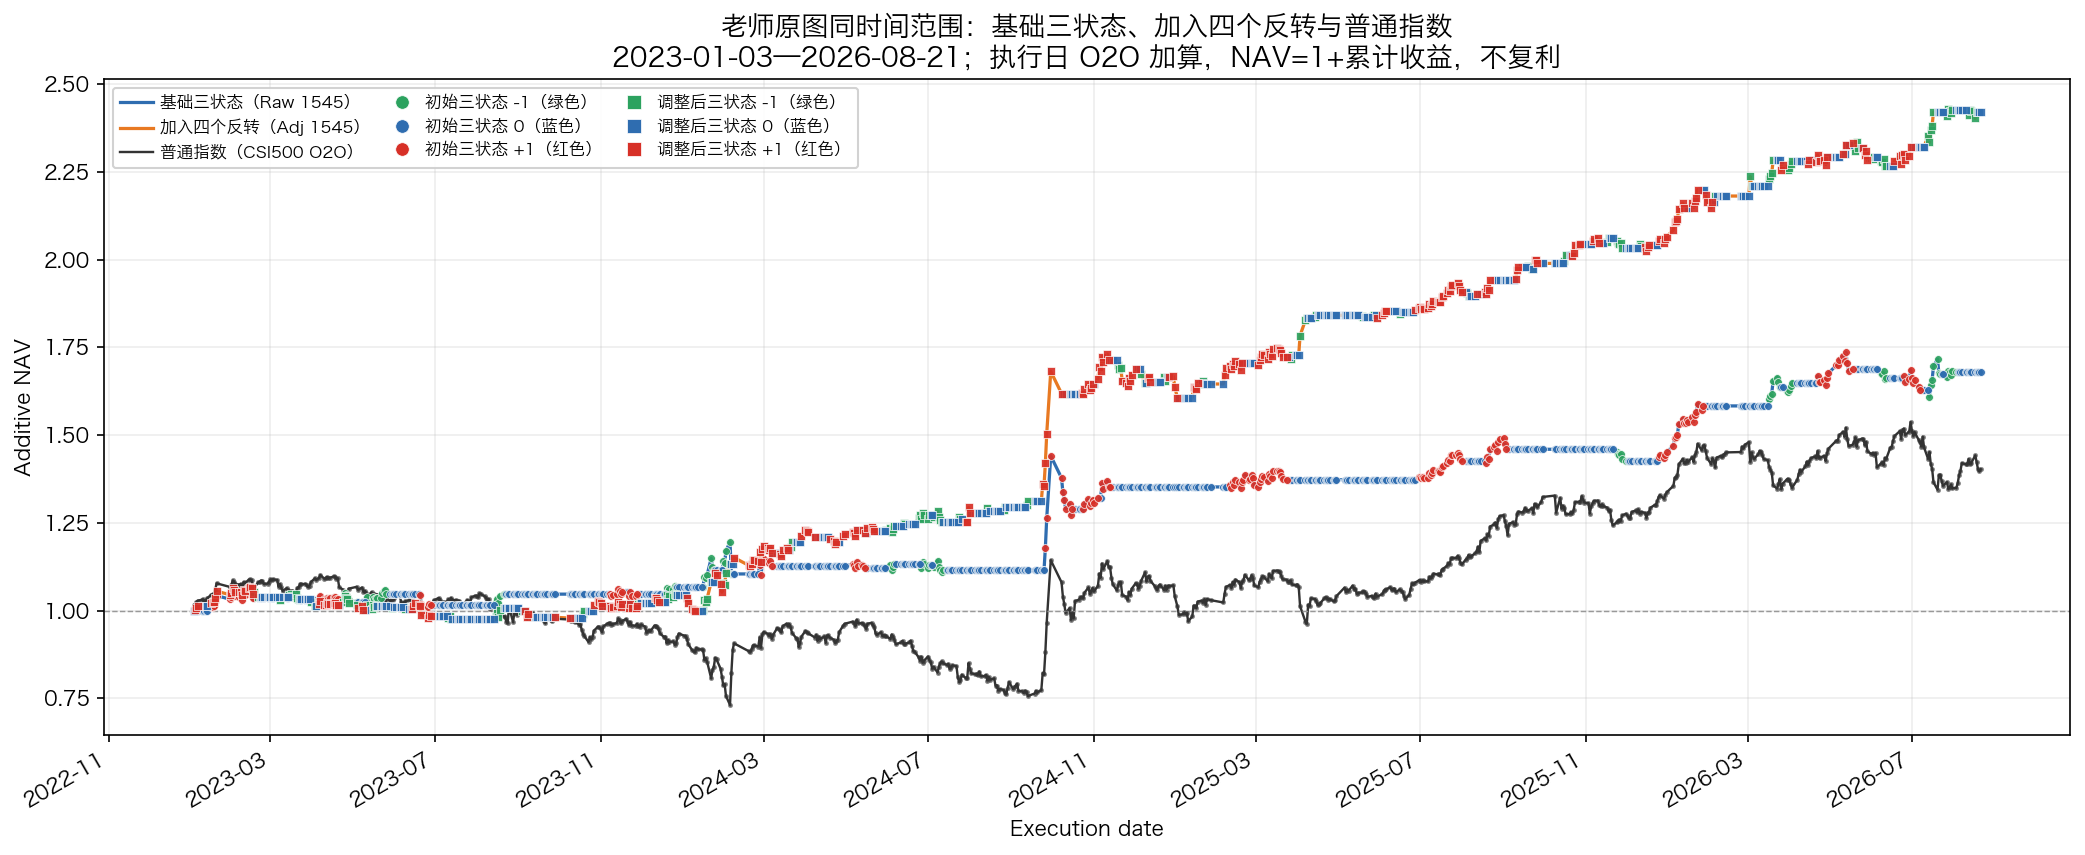

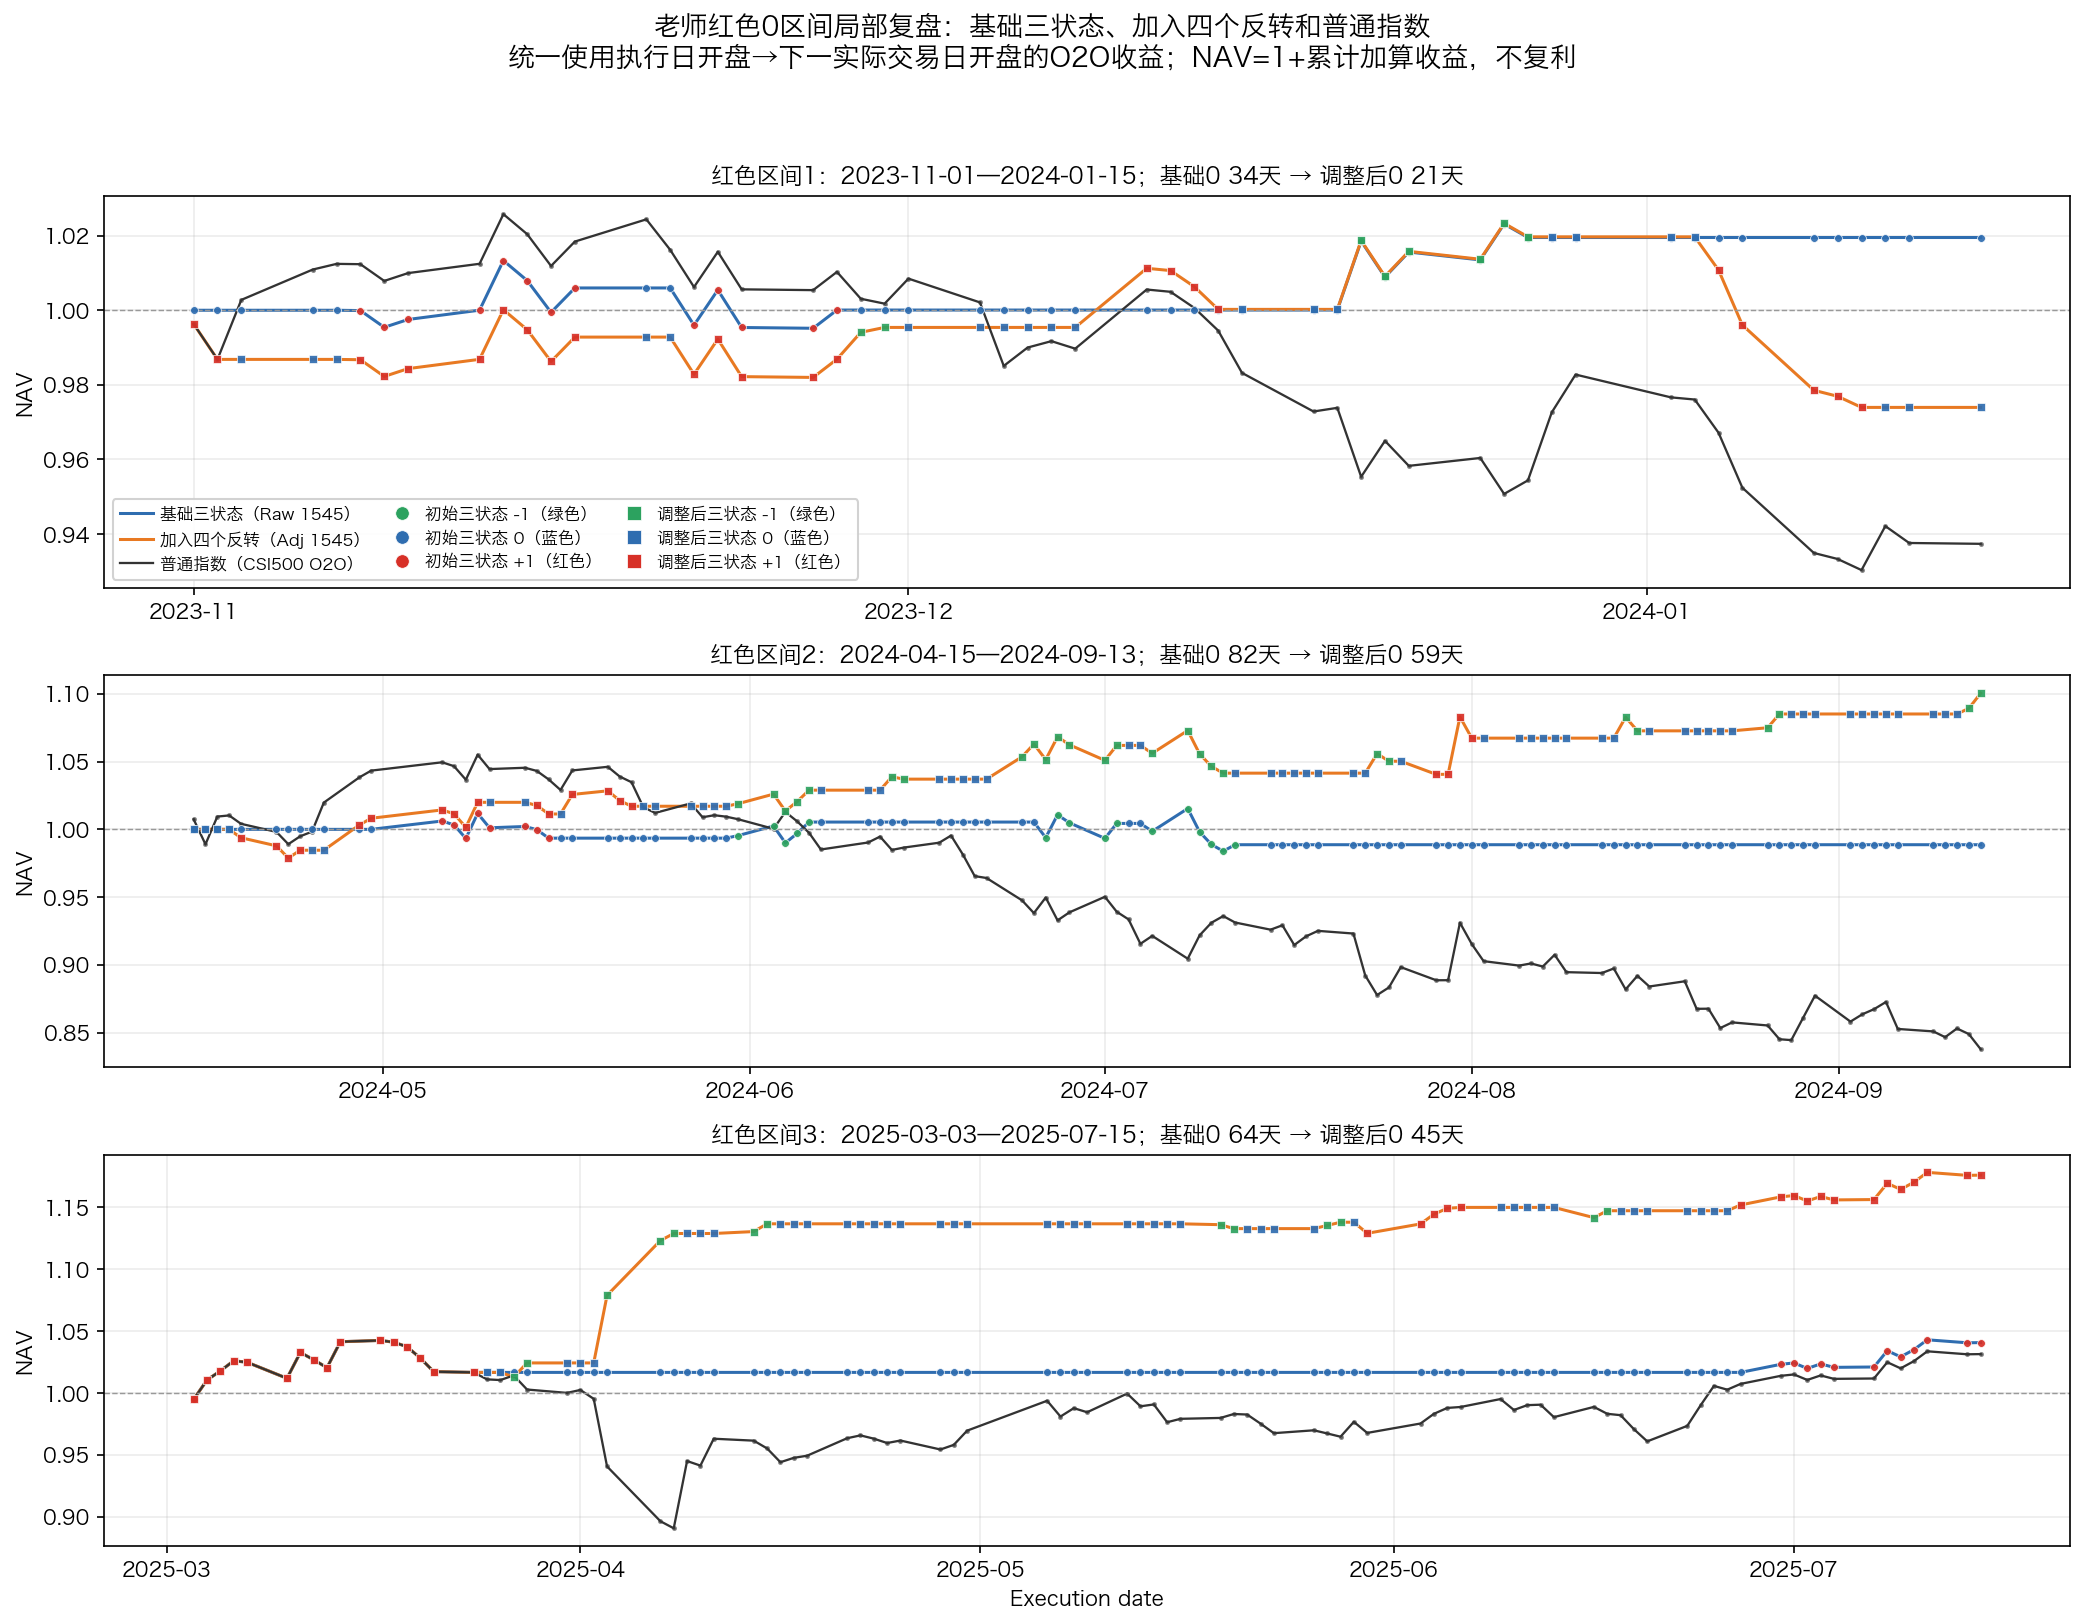

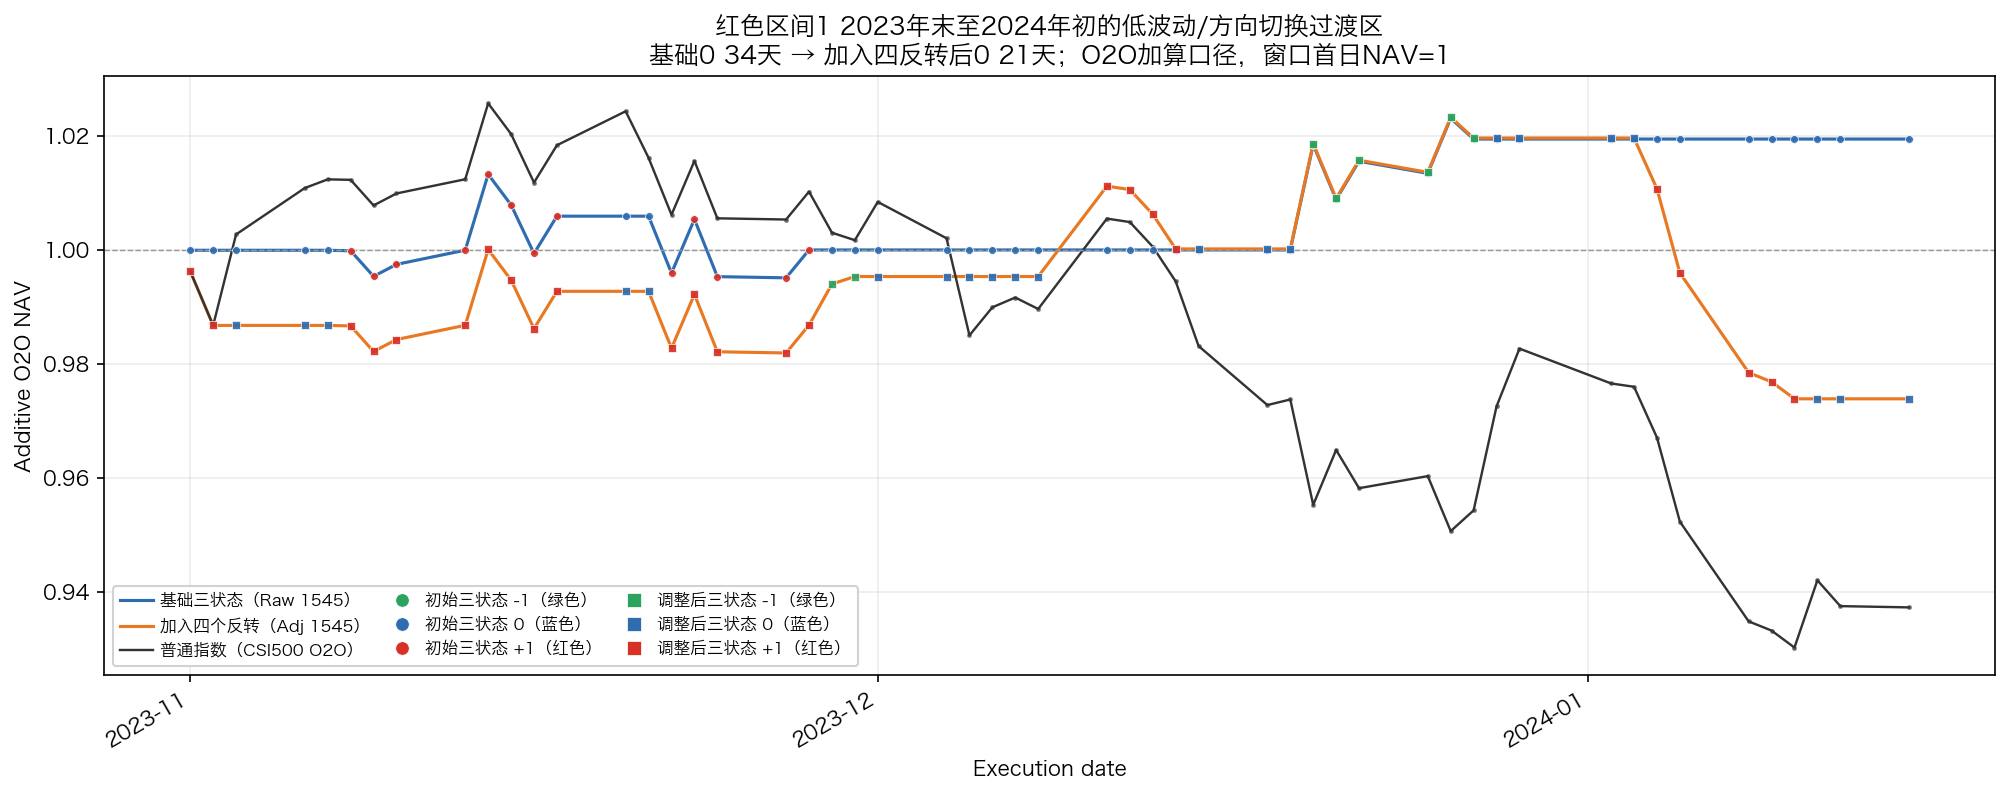

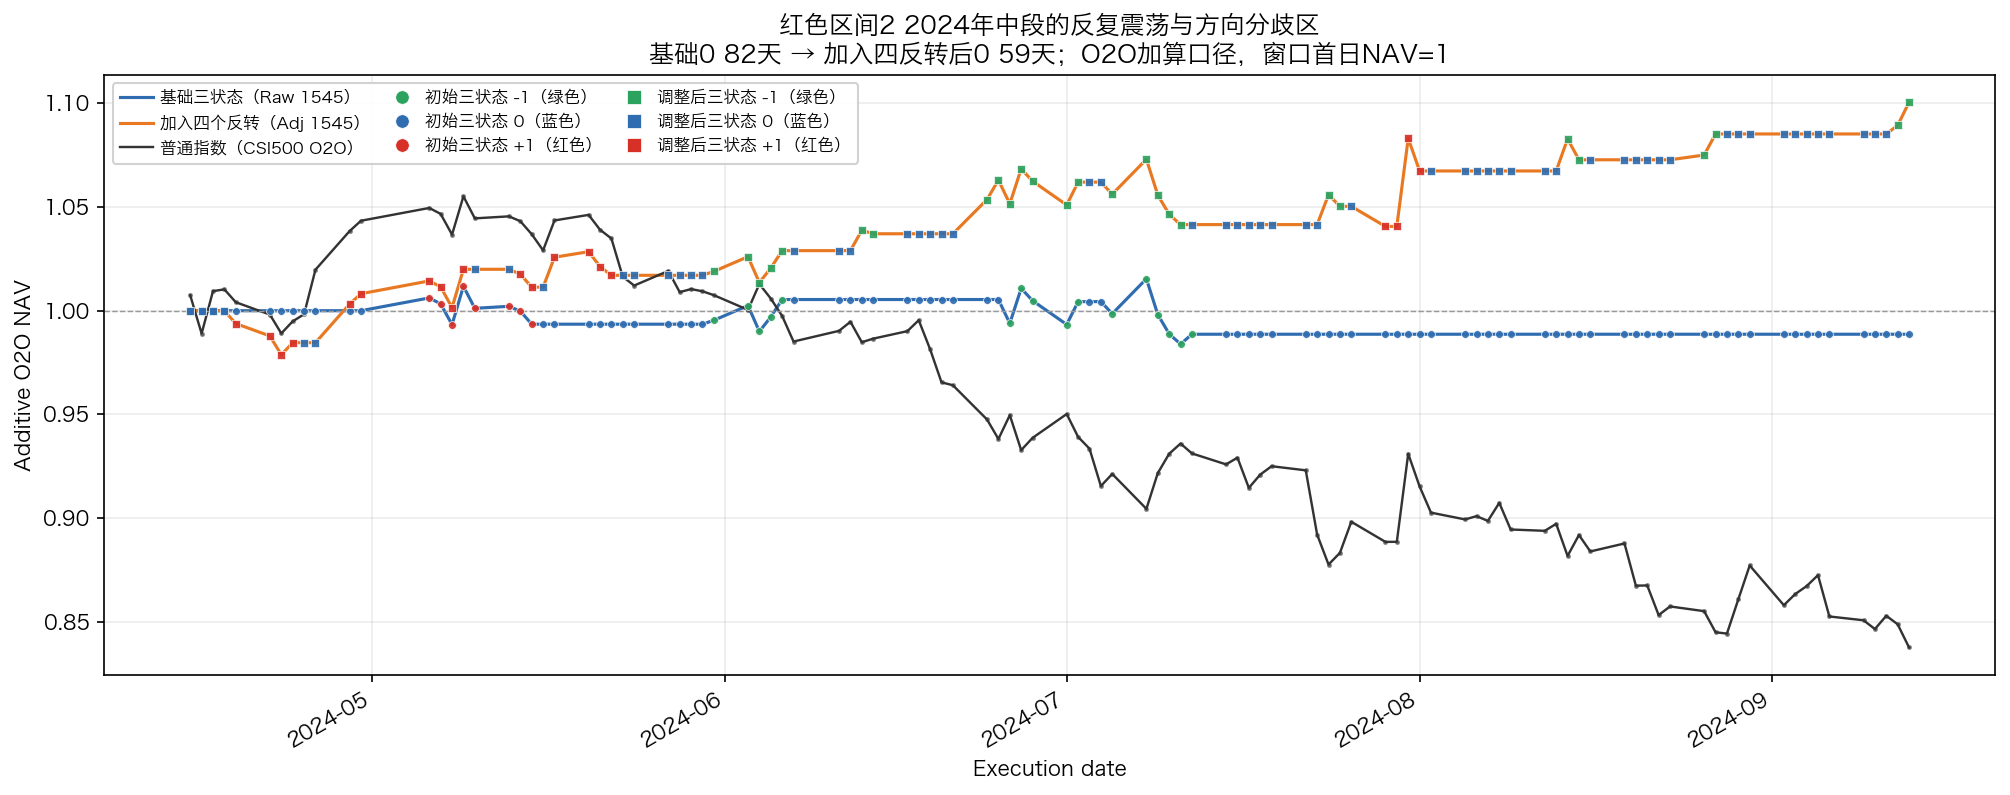

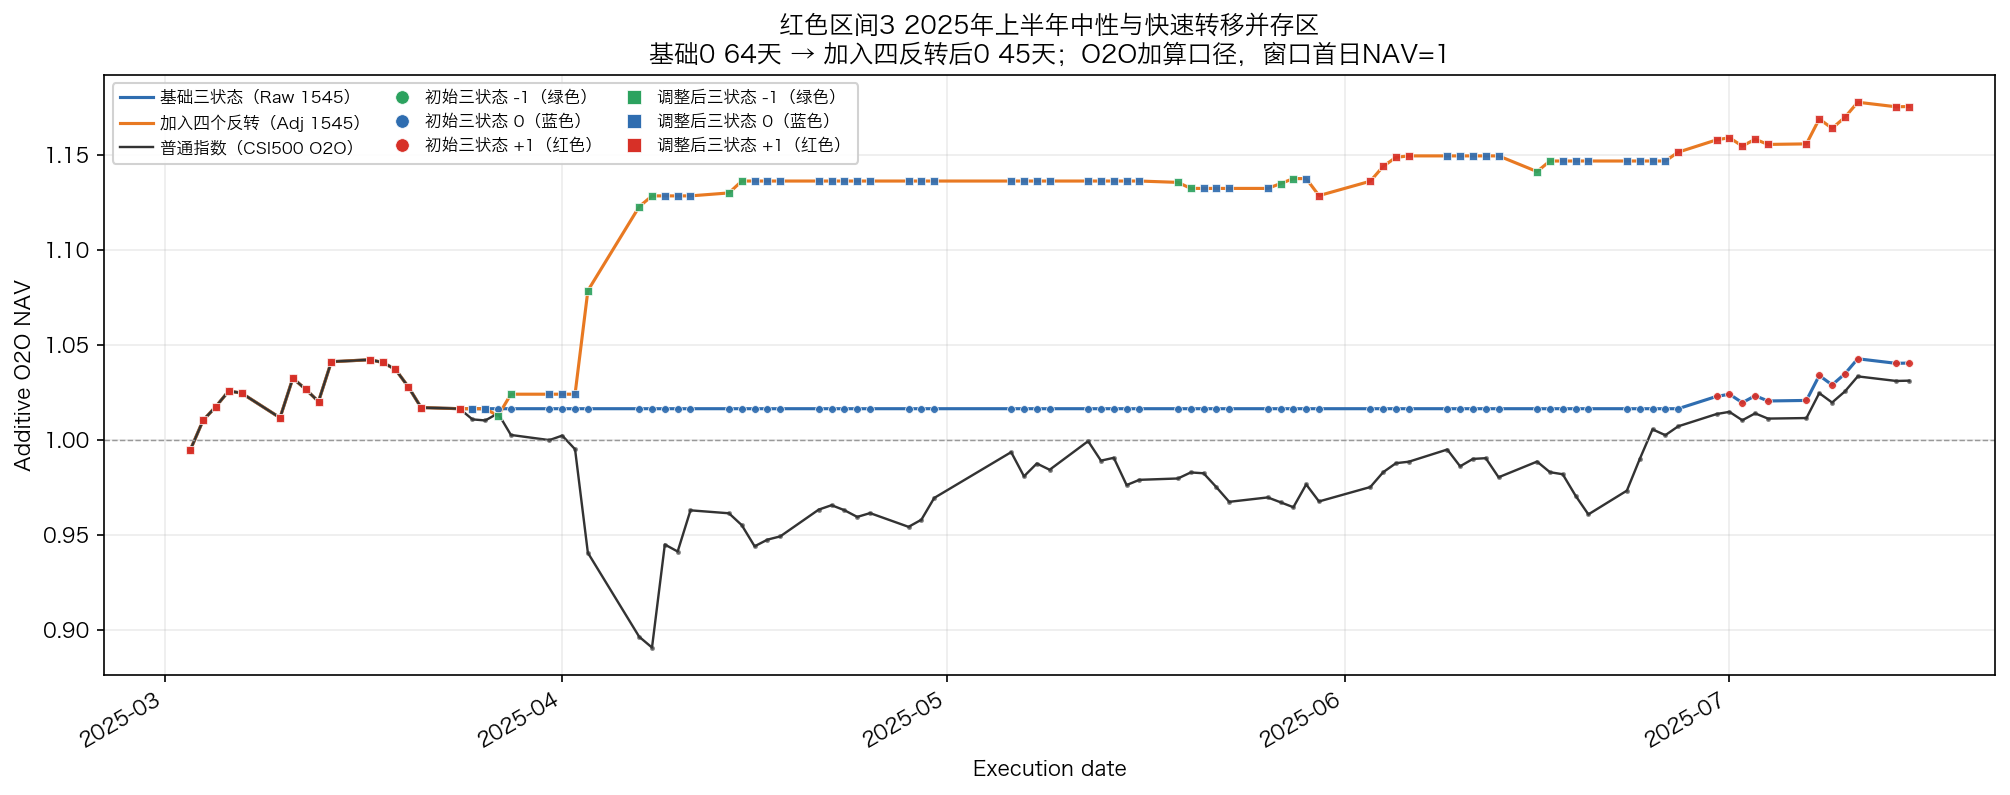

In [4]:
from IPython.display import Image

teacher_summary = pd.read_csv(OUTPUT_DIR / 'tables/老师红色区间复盘汇总_O2O.csv', encoding='utf-8-sig')
display(teacher_summary)
display(Image(filename=str(OUTPUT_DIR / 'figures/29_老师原图同时间范围_2023至最新_三状态与指数_O2O.png')))
display(Image(filename=str(OUTPUT_DIR / 'figures/28_老师红色区间_三状态与指数_O2O局部复盘.png')))
for figure_name in [
    '28A_红色区间1_三状态与指数_O2O局部复盘.png',
    '28B_红色区间2_三状态与指数_O2O局部复盘.png',
    '28C_红色区间3_三状态与指数_O2O局部复盘.png',
]:
    display(Image(filename=str(OUTPUT_DIR / 'figures' / figure_name)))